## Installing LaTeX on Google Colab

This is required if you want to save your plots in the `.pgf` format which LaTeX understands.

In [1]:
%%capture

!apt-get install -y texlive-xetex texlive-fonts-recommended cm-super

# Convergence of Standard SVM to SVM-GMU under Increasing Sampling

This experiment demonstrates, on the `close_separable` dataset, that a standard SVM fit to a growing cloud of samples drawn from the per-sample GMM uncertainty distributions converges to the SVM-GMU decision boundary fit to the original 6 observed points. The SVM-GMU objective in Equation 67 of the report minimizes a *regularized expected hinge loss*, where the expectation is taken over each per-sample GMM:

$$
\mathcal{J}(\mathbf{w}, b) \;=\; \frac{\lambda}{2}\|\mathbf{w}\|^2
\;+\; \frac{1}{n}\sum_{i=1}^{n}
\mathbb{E}_{\mathbf{x} \sim f_i}\Bigl[\max\left(0,\; 1 - y_i\left(\mathbf{w}^\intercal \mathbf{x} + b\right)\right)\Bigr].
$$

If we replace each expectation by a Monte Carlo average over $N$ IID draws from $f_i$, assign every draw the label $y_i$ of its parent, and train a *standard* SVM on the resulting cloud of $6N$ points, the empirical hinge loss converges to the SVM-GMU objective as $N \to \infty$ (law of large numbers). So the minimizer of the standard-SVM objective on that cloud should converge to the SVM-GMU minimizer on the original 6 points.

The experiment below verifies this by sweeping $N$ over several orders of magnitude, training a standard SVM at each $N$, and measuring how close its decision boundary gets to the SVM-GMU boundary.

In [2]:
%%capture

# Installing svm-gmu
!pip install git+https://github.com/SushrutGaikwad/svm-gmu.git

## 1. Imports

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from svm_gmu import SvmGmu
from svm_gmu.plotting import plot_boundary

## 2. Dataset

We use the exact same dataset as `examples/close_separable.ipynb`: 6 observed points in 2-D (3 per class) with banana- and crescent-shaped GMM uncertainties of 5 to 6 components each.

In [4]:
X = np.array([
    [-1.8,  0.0],   # +1
    [-2.0,  1.5],   # +1
    [-1.0,  2.5],   # +1
    [ 1.5, -1.0],   # -1
    [ 1.0,  1.0],   # -1
    [ 2.0,  2.0],   # -1
])
y = np.array([+1, +1, +1, -1, -1, -1])


In [5]:
sample_1 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [-4.2, -0.3],
        [-3.8,  0.3],
        [-3.0,  0.5],
        [-2.2,  0.3],
        [-1.8, -0.3],
    ]),
    "covariances": np.array([
        [[ 0.08, -0.05], [-0.05,  0.15]],
        [[ 0.10, -0.03], [-0.03,  0.12]],
        [[ 0.18,  0.00], [ 0.00,  0.06]],
        [[ 0.10,  0.03], [ 0.03,  0.12]],
        [[ 0.08,  0.05], [ 0.05,  0.15]],
    ]),
}

sample_2 = {
    "weights": np.array([0.08, 0.15, 0.22, 0.30, 0.15, 0.10]),
    "means": np.array([
        [-2.2,  0.6],
        [-1.8,  1.1],
        [-1.4,  1.5],
        [-0.8,  1.7],
        [-0.4,  1.5],
        [-0.1,  1.1],
    ]),
    "covariances": np.array([
        [[ 0.07,  0.04], [ 0.04,  0.13]],
        [[ 0.09,  0.03], [ 0.03,  0.10]],
        [[ 0.14,  0.02], [ 0.02,  0.07]],
        [[ 0.18,  0.00], [ 0.00,  0.05]],
        [[ 0.12, -0.02], [-0.02,  0.07]],
        [[ 0.08, -0.04], [-0.04,  0.12]],
    ]),
}

sample_3 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [-0.6,  2.2],
        [-0.2,  2.7],
        [ 0.3,  3.0],
        [ 0.8,  3.4],
        [ 1.1,  3.8],
    ]),
    "covariances": np.array([
        [[ 0.14, -0.06], [-0.06,  0.08]],
        [[ 0.12, -0.07], [-0.07,  0.10]],
        [[ 0.10, -0.05], [-0.05,  0.14]],
        [[ 0.08,  0.03], [ 0.03,  0.16]],
        [[ 0.10,  0.06], [ 0.06,  0.15]],
    ]),
}

sample_4 = {
    "weights": np.array([0.08, 0.17, 0.25, 0.25, 0.17, 0.08]),
    "means": np.array([
        [-0.9, -0.3],
        [-0.5, -0.7],
        [-0.1, -1.0],
        [ 0.4, -1.2],
        [ 0.8, -1.1],
        [ 1.1, -0.8],
    ]),
    "covariances": np.array([
        [[ 0.07,  0.04], [ 0.04,  0.12]],
        [[ 0.09,  0.03], [ 0.03,  0.10]],
        [[ 0.15,  0.00], [ 0.00,  0.07]],
        [[ 0.15,  0.00], [ 0.00,  0.07]],
        [[ 0.09, -0.03], [-0.03,  0.10]],
        [[ 0.12, -0.05], [-0.05,  0.09]],
    ]),
}

sample_5 = {
    "weights": np.array([0.10, 0.20, 0.40, 0.20, 0.10]),
    "means": np.array([
        [1.3,  0.7],
        [1.7,  0.3],
        [2.3,  0.1],
        [2.9,  0.3],
        [3.3,  0.7],
    ]),
    "covariances": np.array([
        [[ 0.09,  0.05], [ 0.05,  0.14]],
        [[ 0.12,  0.03], [ 0.03,  0.10]],
        [[ 0.16,  0.00], [ 0.00,  0.07]],
        [[ 0.12, -0.03], [-0.03,  0.10]],
        [[ 0.09, -0.05], [-0.05,  0.14]],
    ]),
}

sample_6 = {
    "weights": np.array([0.08, 0.17, 0.25, 0.25, 0.17, 0.08]),
    "means": np.array([
        [2.4,  2.3],
        [2.8,  2.0],
        [3.3,  2.0],
        [3.8,  2.1],
        [4.2,  2.5],
        [4.4,  3.0],
    ]),
    "covariances": np.array([
        [[ 0.08,  0.05], [ 0.05,  0.11]],
        [[ 0.12,  0.03], [ 0.03,  0.08]],
        [[ 0.15,  0.00], [ 0.00,  0.06]],
        [[ 0.13, -0.02], [-0.02,  0.07]],
        [[ 0.09, -0.04], [-0.04,  0.10]],
        [[ 0.07, -0.05], [-0.05,  0.12]],
    ]),
}

sample_uncertainty = [sample_1, sample_2, sample_3,
                      sample_4, sample_5, sample_6]

## 3. Reference SVM-GMU Boundary

We train the uncertainty-aware SVM-GMU on the 6 observed points with their full GMM uncertainty. This is the target boundary that the standard-SVM-on-samples boundary should converge to.

In [6]:
REF_LAM = 0.01
REF_SEED = 42

model_gmu = SvmGmu(
    lam=REF_LAM,
    max_iter=1000,
    batch_size=6,
    random_state=REF_SEED,
    verbose=False,
)
model_gmu.fit(X, y, sample_uncertainty=sample_uncertainty)

w_ref = model_gmu.coef_.copy()
b_ref = float(model_gmu.intercept_)
print(f"SVM-GMU reference:  w = {w_ref},  b = {b_ref:.4f}")
print(f"||w_ref|| = {np.linalg.norm(w_ref):.4f}")


SVM-GMU reference:  w = [-1.25267325  1.25886418],  b = -0.9470
||w_ref|| = 1.7759


## 4. Sampling from the GMMs

For each observed point $i$, draw $N$ IID samples from its GMM $f_i$. Each sample inherits the label $y_i$ of its parent. The resulting expanded dataset has $6N$ points and is the input to the standard SVM.

The sampler picks a mixture component according to the weight vector $\pi_i$, then draws from that component's Gaussian.

In [7]:
def sample_from_gmm(gmm: dict, n_samples: int, rng: np.random.Generator) -> np.ndarray:
    """Draw ``n_samples`` IID points from a single GMM.

    Parameters
    ----------
    gmm : dict
        Dict with keys 'weights', 'means', 'covariances' (full covariance).
    n_samples : int
        Number of samples to draw.
    rng : np.random.Generator
        Random number generator for reproducibility.

    Returns
    -------
    ndarray of shape (n_samples, d)
    """
    weights = gmm["weights"]
    means = gmm["means"]
    covs = gmm["covariances"]
    n_components, d = means.shape

    # 1. Choose a component for each sample.
    comp_idx = rng.choice(n_components, size=n_samples, p=weights)

    # 2. Draw from the chosen Gaussian.
    out = np.empty((n_samples, d), dtype=np.float64)
    for m in range(n_components):
        mask = comp_idx == m
        k = int(mask.sum())
        if k == 0:
            continue
        out[mask] = rng.multivariate_normal(means[m], covs[m], size=k)
    return out


def build_expanded_dataset(
    sample_uncertainty: list[dict],
    y: np.ndarray,
    n_per_gmm: int,
    rng: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    """Draw ``n_per_gmm`` samples from each sample's GMM and stack them."""
    X_parts, y_parts = [], []
    for i, gmm in enumerate(sample_uncertainty):
        Xi = sample_from_gmm(gmm, n_per_gmm, rng)
        X_parts.append(Xi)
        y_parts.append(np.full(n_per_gmm, y[i], dtype=np.float64))
    X_exp = np.vstack(X_parts)
    y_exp = np.concatenate(y_parts)
    return X_exp, y_exp


## 5. Sweep over sample sizes

Here $N$ is the number of Monte Carlo draws per observed point, and $n = 6N$ is the resulting standard-SVM training set size, which is the same $n$ used in the report to denote the number of training examples.

For each value of $N$, we:

1. Draw an expanded dataset of size $n = 6N$ from the GMMs.
2. Fit a *standard* linear SVM on that expanded dataset by calling `SvmGmu.fit` with `sample_uncertainty=None`.
3. Record $(\mathbf{w}_N, b_N)$ and compute three error metrics against the reference SVM-GMU boundary.

**Error metrics.**

- Angle between normals: $\theta_N = \arccos\bigl(\langle \hat{\mathbf{w}}_N, \hat{\mathbf{w}}_{\text{ref}} \rangle\bigr)$ in degrees, where $\hat{\mathbf{w}} = \frac{\mathbf{w}}{\|\mathbf{w}\|}$. This is how much the two boundary *orientations* disagree.
- Offset difference: $\left|\frac{b_N}{\|\mathbf{w}_N\|} - \frac{b_{\text{ref}}}{\|\mathbf{w}_{\text{ref}}\|}\right|$. Since $-\frac{b}{\|\mathbf{w}\|}$ is the signed distance from the origin to the boundary, this measures how much the boundaries are shifted apart perpendicular to the normal.
- Grid L2 distance: root-mean-square absolute difference of the two decision functions $\mathbf{w}^\intercal \mathbf{x} + b$, evaluated on a dense grid over the plotting window, after normalizing each $\mathbf{w}$ to unit norm. This captures overall boundary disagreement as a single scalar.

All three should tend to zero as $N \to \infty$.

In [8]:
N_VALUES = [1, 5, 25, 100, 500, 2000, 5000, 20000]
EXP_SEED = 2026

# Fixed grid for the boundary-distance metric.
_grid_x = np.linspace(-5, 5, 60)
_grid_y = np.linspace(-4, 5, 60)
_GX, _GY = np.meshgrid(_grid_x, _grid_y)
_GRID_PTS = np.column_stack([_GX.ravel(), _GY.ravel()])


def boundary_metrics(w_a, b_a, w_b, b_b):
    """Return (angle_deg, offset_diff, grid_rms) between two linear boundaries."""
    wa_hat = w_a / np.linalg.norm(w_a)
    wb_hat = w_b / np.linalg.norm(w_b)
    cos_t = np.clip(np.dot(wa_hat, wb_hat), -1.0, 1.0)
    angle_deg = float(np.degrees(np.arccos(cos_t)))

    offset_a = b_a / np.linalg.norm(w_a)
    offset_b = b_b / np.linalg.norm(w_b)
    offset_diff = float(abs(offset_a - offset_b))

    # RMS of (hat_f_a - hat_f_b) on a dense grid, where hat_f uses unit-norm w.
    f_a = _GRID_PTS @ wa_hat + offset_a
    f_b = _GRID_PTS @ wb_hat + offset_b
    grid_rms = float(np.sqrt(np.mean((f_a - f_b) ** 2)))

    return angle_deg, offset_diff, grid_rms


records = []
master_rng = np.random.default_rng(EXP_SEED)

for N in N_VALUES:
    # Sample the expanded cloud.
    sample_rng = np.random.default_rng(master_rng.integers(0, 2**31 - 1))
    X_exp, y_exp = build_expanded_dataset(sample_uncertainty, y, N, sample_rng)

    # Train a standard linear SVM (no uncertainty).
    # Scale max_iter gently with dataset size so SGD can converge.
    max_iter = max(2000, 500 * int(np.log10(max(X_exp.shape[0], 10)) + 1))
    batch_size = min(256, X_exp.shape[0])

    model_n = SvmGmu(
        lam=REF_LAM,
        max_iter=max_iter,
        batch_size=batch_size,
        random_state=REF_SEED,
        verbose=False,
    )
    model_n.fit(X_exp, y_exp)

    w_n = model_n.coef_.copy()
    b_n = float(model_n.intercept_)
    angle, offset_diff, grid_rms = boundary_metrics(w_n, b_n, w_ref, b_ref)

    records.append({
        "N": N,
        "n_total": X_exp.shape[0],
        "w": w_n,
        "b": b_n,
        "angle_deg": angle,
        "offset_diff": offset_diff,
        "grid_rms": grid_rms,
        "X_exp": X_exp,
        "y_exp": y_exp,
        "model": model_n,
    })

    print(
        f"N={N:>6d}  |  n={X_exp.shape[0]:>7d}  |  "
        f"angle={angle:7.3f} deg  |  offset_diff={offset_diff:.4f}  |  "
        f"grid_rms={grid_rms:.4f}"
    )


N=     1  |  n=      6  |  angle=  9.342 deg  |  offset_diff=1.0432  |  grid_rms=1.0917
N=     5  |  n=     30  |  angle=  4.261 deg  |  offset_diff=0.1404  |  grid_rms=0.2662
N=    25  |  n=    150  |  angle=  0.200 deg  |  offset_diff=0.1921  |  grid_rms=0.1912
N=   100  |  n=    600  |  angle=  1.266 deg  |  offset_diff=0.0463  |  grid_rms=0.0727
N=   500  |  n=   3000  |  angle=  0.482 deg  |  offset_diff=0.0231  |  grid_rms=0.0309
N=  2000  |  n=  12000  |  angle=  0.233 deg  |  offset_diff=0.0242  |  grid_rms=0.0280
N=  5000  |  n=  30000  |  angle=  0.244 deg  |  offset_diff=0.0032  |  grid_rms=0.0128
N= 20000  |  n= 120000  |  angle=  0.217 deg  |  offset_diff=0.0005  |  grid_rms=0.0106


### Summary table

In [9]:
print(f"{'N':>10s}  {'n':>10s}  "
      f"{'angle (deg)':>12s}  {'offset diff':>12s}  {'grid RMS':>10s}")
print("-" * 62)
for r in records:
    print(
        f"{r['N']:>10d}  {r['n_total']:>10d}  "
        f"{r['angle_deg']:>12.4f}  {r['offset_diff']:>12.4f}  "
        f"{r['grid_rms']:>10.4f}"
    )

print()
print(f"Reference SVM-GMU:  w = {w_ref},  b = {b_ref:.4f}")


         N           n   angle (deg)   offset diff    grid RMS
--------------------------------------------------------------
         1           6        9.3425        1.0432      1.0917
         5          30        4.2608        0.1404      0.2662
        25         150        0.1996        0.1921      0.1912
       100         600        1.2658        0.0463      0.0727
       500        3000        0.4823        0.0231      0.0309
      2000       12000        0.2334        0.0242      0.0280
      5000       30000        0.2437        0.0032      0.0128
     20000      120000        0.2168        0.0005      0.0106

Reference SVM-GMU:  w = [-1.25267325  1.25886418],  b = -0.9470


## 6. Convergence curve

All three metrics are plotted against $N$ on a log-x axis. If the experiment works, every curve should trend toward zero.

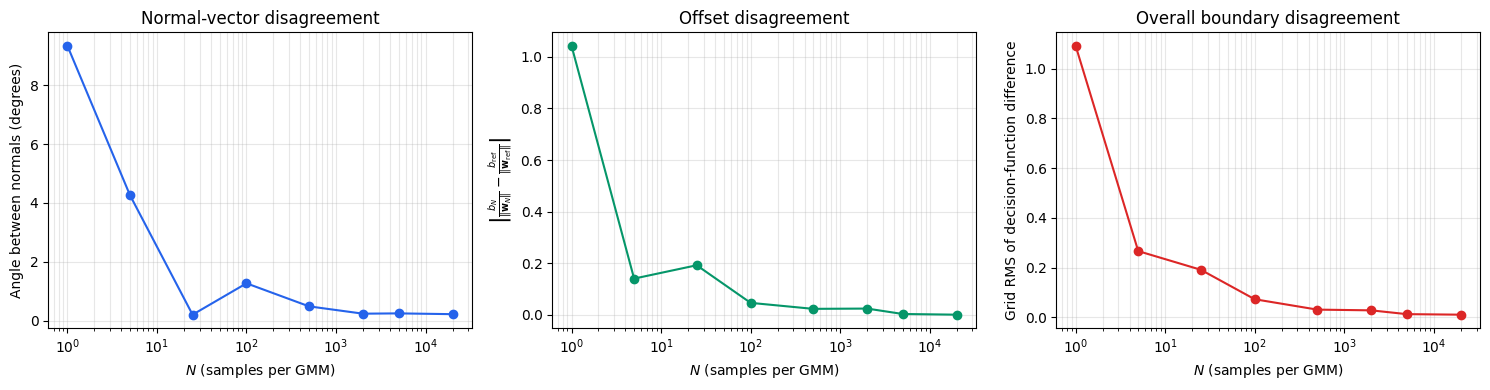

In [10]:
Ns = np.array([r['N'] for r in records], dtype=float)
angles = np.array([r['angle_deg'] for r in records])
offsets = np.array([r['offset_diff'] for r in records])
rms = np.array([r['grid_rms'] for r in records])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(Ns, angles, marker="o", color="#2563eb")
axes[0].set_xscale("log")
axes[0].set_xlabel(r"$N$ (samples per GMM)")
axes[0].set_ylabel("Angle between normals (degrees)")
axes[0].set_title("Normal-vector disagreement")
axes[0].grid(True, which="both", alpha=0.3)

axes[1].plot(Ns, offsets, marker="o", color="#059669")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$N$ (samples per GMM)")
axes[1].set_ylabel(r"$\left|\frac{b_N}{\|\mathbf{w}_N\|} - \frac{b_{\text{ref}}}{\|\mathbf{w}_{\text{ref}}\|}\right|$")
axes[1].set_title("Offset disagreement")
axes[1].grid(True, which="both", alpha=0.3)

axes[2].plot(Ns, rms, marker="o", color="#dc2626")
axes[2].set_xscale("log")
axes[2].set_xlabel(r"$N$ (samples per GMM)")
axes[2].set_ylabel("Grid RMS of decision-function difference")
axes[2].set_title("Overall boundary disagreement")
axes[2].grid(True, which="both", alpha=0.3)

# fig.suptitle(
#     r"Standard SVM boundary approaches SVM-GMU as $N$ grows",
#     y=1.02, fontsize=13,
# )
fig.tight_layout()
plt.show()


## 7. Visual convergence: boundaries at each $N$

We plot one panel per value of $N$, each showing:

- The GMM contours for the 6 observed points (blue for $+1$, red for $-1$).
- The sampled cloud used to train that panel's standard SVM.
- The reference **SVM-GMU** boundary (dashed green).
- The standard-SVM boundary fit to the cloud (solid black).

As $N$ grows, the black line should visibly pull toward the dashed green line.

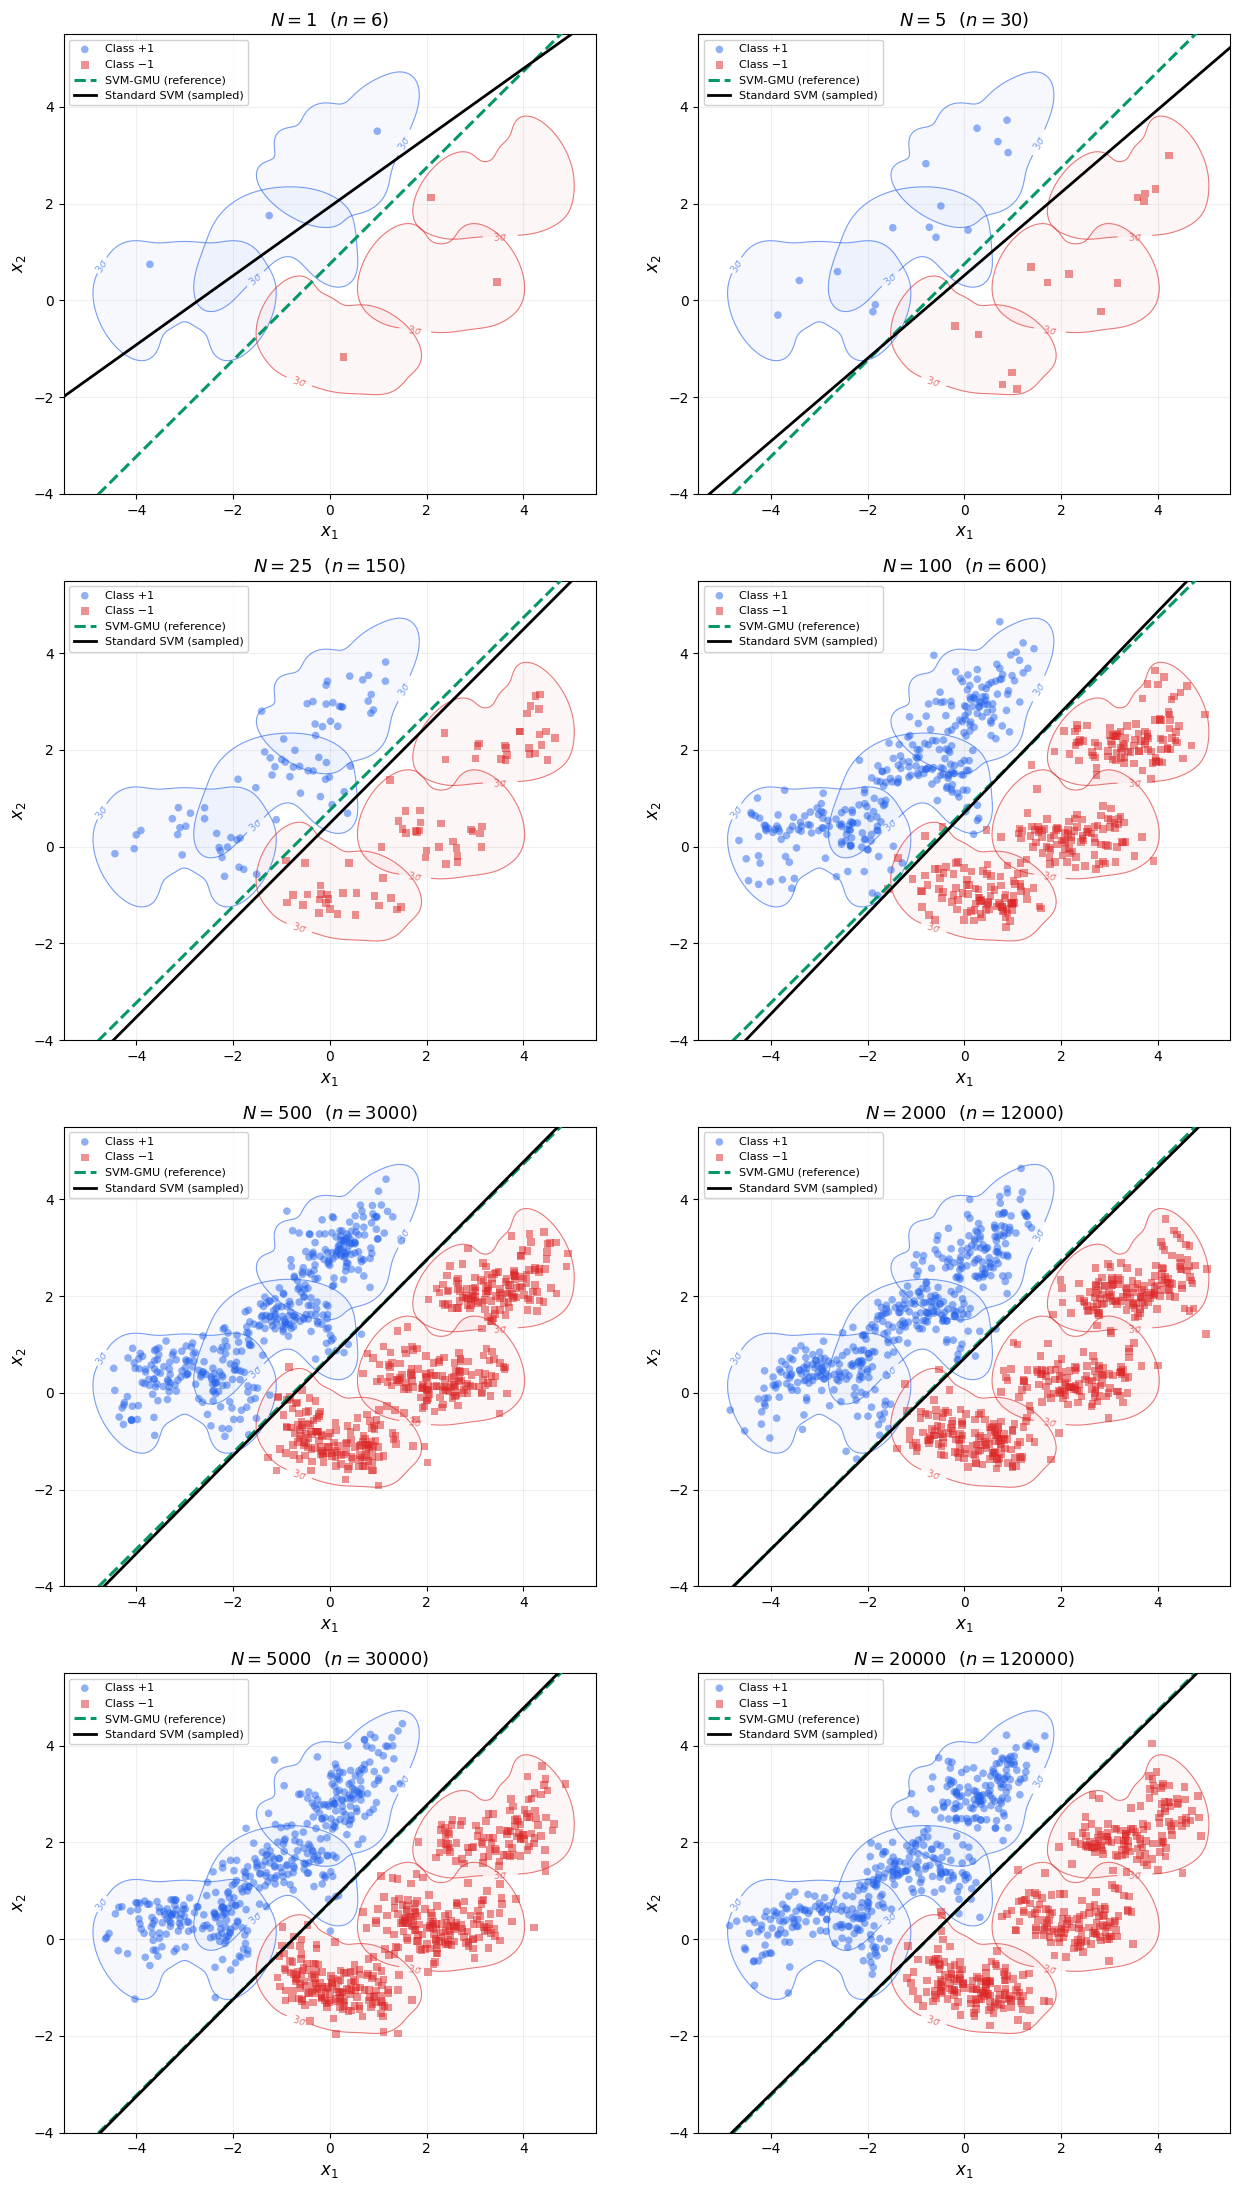

In [11]:
# Build a grid of boundary plots: one panel per value of N.
import math

from svm_gmu.plotting import plot_uncertainty

n_panels = len(records)
n_cols = 2
n_rows = 4

fig, axes = plt.subplots(
    n_rows, n_cols, figsize=(6.5 * n_cols, 5.5 * n_rows),
)
axes = np.array(axes).reshape(n_rows, n_cols)

# Cap the number of scattered sample points to avoid clutter in later panels.
SCATTER_CAP = 800
scatter_rng = np.random.default_rng(EXP_SEED + 1)


def _draw_line(ax, w, b, xlim, **kwargs):
    """Draw the line w^T x + b = 0 within the given x-limits."""
    xs = np.linspace(xlim[0], xlim[1], 400)
    if abs(w[1]) > 1e-8:
        ys = -(w[0] * xs + b) / w[1]
        return ax.plot(xs, ys, **kwargs)[0]
    x_vert = -b / w[0]
    return ax.axvline(x_vert, **kwargs)


REF_COLOR = "#059669"   # green for the SVM-GMU reference
STD_COLOR = "black"     # black for the standard SVM on sampled data

for k, r in enumerate(records):
    ax = axes[k // n_cols, k % n_cols]

    # Layer 1: GMM contours (plot_uncertainty draws contours AND the 6 original
    # X points; we strip the points afterwards so only contours remain).
    plot_uncertainty(
        X, y, sample_uncertainty,
        sigmas=(3,),
        title=rf"$N = {r['N']}$  $\left(n = {r['n_total']}\right)$",
        ax=ax,
    )
    # Remove the scatter of the 6 observed points drawn by plot_uncertainty.
    for coll in list(ax.collections):
        if isinstance(coll, plt.matplotlib.collections.PathCollection):
            coll.remove()

    # Layer 2: plot the sampled cloud, subsampled if huge. Bigger, more opaque
    # markers so individual points are easy to see.
    X_exp, y_exp = r["X_exp"], r["y_exp"]
    if X_exp.shape[0] > SCATTER_CAP:
        idx = scatter_rng.choice(X_exp.shape[0], size=SCATTER_CAP, replace=False)
        X_plot, y_plot = X_exp[idx], y_exp[idx]
    else:
        X_plot, y_plot = X_exp, y_exp
    for label, color, marker, class_label in [
        (+1, "#2563eb", "o", "Class +1"),
        (-1, "#dc2626", "s", "Class \u22121"),
    ]:
        mask = y_plot == label
        ax.scatter(
            X_plot[mask, 0], X_plot[mask, 1],
            s=30, c=color, marker=marker,
            alpha=0.5, edgecolors="none", zorder=2,
            label=class_label,
        )

    # Give every panel the same axes limits so the boundary lines are
    # comparable across N. Using the original dataset's plotting window.
    xlim = (-5.5, 5.5)
    ylim = (-4.0, 5.5)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Layer 3: SVM-GMU reference boundary (green dashed).
    _draw_line(
        ax, w_ref, b_ref, xlim,
        color=REF_COLOR, linewidth=2.2, linestyle="--", zorder=4,
        label="SVM-GMU (reference)",
    )

    # Layer 4: standard-SVM boundary fit on the sampled cloud (black solid).
    _draw_line(
        ax, r["w"], r["b"], xlim,
        color=STD_COLOR, linewidth=2.0, linestyle="-", zorder=5,
        label="Standard SVM (sampled)",
    )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    # Rebuild a clean legend (plot_uncertainty added contour entries; keep
    # only point-class entries plus our two boundary entries).
    handles, labels = ax.get_legend_handles_labels()
    keep_labels = {"Class +1", "Class \u22121",
                   "SVM-GMU (reference)", "Standard SVM (sampled)"}
    seen = set()
    uniq = []
    for h, l in zip(handles, labels):
        if l in keep_labels and l not in seen:
            seen.add(l)
            uniq.append((h, l))
    ax.legend([h for h, _ in uniq], [l for _, l in uniq],
              loc="upper left", fontsize=8, framealpha=0.9)

# Hide any unused subplots.
for k in range(n_panels, n_rows * n_cols):
    axes[k // n_cols, k % n_cols].axis("off")

fig.tight_layout()
plt.show()


## 8. Interpretation

Both the convergence-metric curves and the boundary grid tell the same story:

- For small $N$ (e.g. $N = 1$ or $N = 5$), the standard-SVM boundary is driven by a handful of draws and can land far from the SVM-GMU boundary.
- As $N$ grows, the empirical hinge loss on the cloud converges to the regularized expected hinge loss of Equation 67. The minimizers converge accordingly, and the black line visibly moves toward the dashed green one.
- By $N = 20{,}000$ (i.e., $n = 120{,}000$ total training points), the two boundaries are close to indistinguishable, confirming the theoretical prediction.

This is a Monte Carlo verification that SVM-GMU is exactly what it claims to be: the closed-form minimizer of the *expected* hinge loss under the per-sample GMM uncertainty, equivalent in the limit to a standard SVM trained on infinitely many samples drawn from that uncertainty.

The practical message is that SVM-GMU buys you this expected-loss behavior *analytically* from only the 6 original points and their GMM descriptions, without any sampling at all.